# Underfitting Model

by Niklas Vogel and Kevin Stupar

## Setup
This notebook creates an underfitting model and evaluates it.

Before executing this please make sure you did download and extract the data using an unzip tool optimized for your OS (`unzip` in WSL could take a long time)
The Download can be done using `setup.sh`

## Data Credit
TODO

# Load the data and split it

In [1]:
from helper import get_data, plot_accuracy_and_loss, plot_confusion_matrix, plot_samples, calculate_predictions, plot_scores
from keras import layers, models

image_size = (64, 64)

(train_images, validation_images, test_images, label_names) = get_data(image_size)

print("Number of training batches: ", len(train_images))
print("Number of validation batches: ", len(validation_images))
print("Number of testing batches: ", len(test_images))
print("Class names: ", label_names)

Number of training batches:  350
Number of validation batches:  87
Number of testing batches:  187
Class names:  ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.

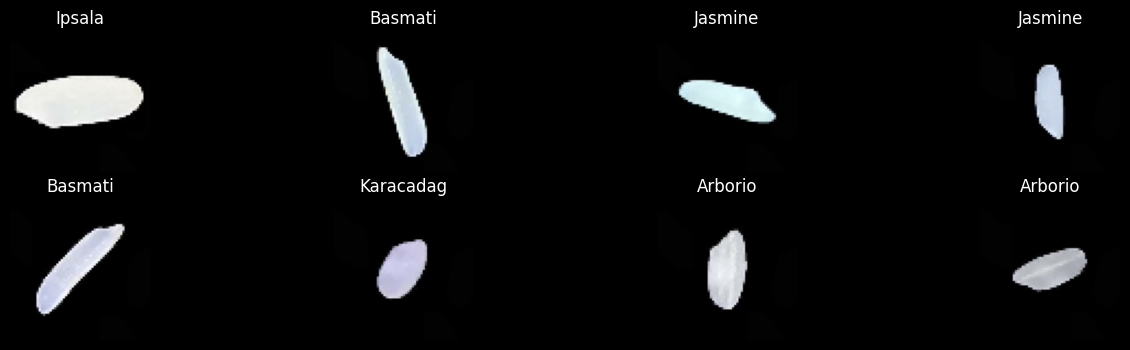

In [2]:
plot_samples(train_images, label_names)

# Building the model

We want an underfitting model, so we will only use two convolutional layers and apply string max-pooling to reduce the numver of parameters.

Since the Images need to have a rather high resolution (64x64), we have nearly 2000 parameters, since else the model would perform very poorly.

In [3]:
model = models.Sequential([
    layers.Input(shape=image_size +(3,)),
    layers.Conv2D(16, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(8, (3,3), activation="relu"),
    layers.MaxPooling2D((8,8)),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,973 (7.71 KB)

 Trainable params: 1,973 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling and Training the model

Now we need to compile and train the model, which could take some time.

In [4]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = model.fit(train_images, epochs=3, validation_data=validation_images)

Epoch 1/3
350/350 ━━━━━━━━━━━━━━━━━━━━ 36s 53ms/step - accuracy: 0.4846 - loss: 4.6074 - val_accuracy: 0.5812 - val_loss: 1.1690
Epoch 2/3
350/350 ━━━━━━━━━━━━━━━━━━━━ 36s 56ms/step - accuracy: 0.6868 - loss: 0.8471 - val_accuracy: 0.7457 - val_loss: 0.6426
Epoch 3/3
350/350 ━━━━━━━━━━━━━━━━━━━━ 38s 59ms/step - accuracy: 0.7781 - loss: 0.5873 - val_accuracy: 0.8068 - val_loss: 0.4886


# Evaluating the model

Using a few plot we can see, that the model is underfitting.
Note that the loss is on a log scale to be able to interpret the results better.

In [5]:
true, pred = calculate_predictions(model, test_images)

AttributeError: Line2D.set() got an unexpected keyword argument 'vmin'

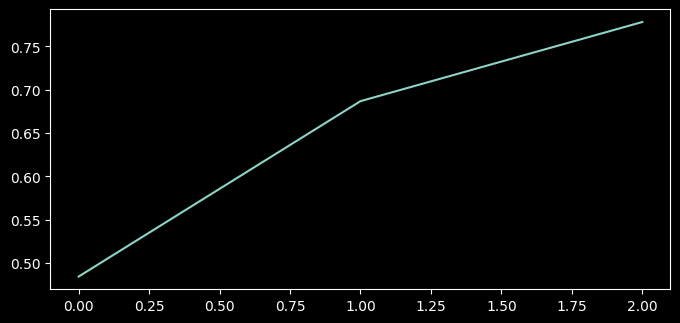

In [6]:
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])

plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)